**EXPERIMENT 4 — Logistic Regression**

Step 1 — Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

Step 2 — Load the dataset

In [ ]:
df = pd.read_csv("placement_predict_50k_Dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (50000, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


Step 3 — Check the important columns

In [ ]:
print(df.columns.tolist())

['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']


In [ ]:
print("\nPlacementStatus:")
print(df["PlacementStatus"].value_counts(dropna=False))


PlacementStatus:
PlacementStatus
1    32856
0    17144
Name: count, dtype: int64


Step 4 — Create CGPA_Tier

In [ ]:
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["PlacementStatus"]
)

print("Training rows:", len(train_df))
print("Validation rows:", len(val_df))

Training rows: 40000
Validation rows: 10000


In [ ]:
q1, q2 = train_df["CGPA"].quantile([1/3, 2/3])

print("CGPA cut points:")
print("Q1 =", q1)
print("Q2 =", q2)

CGPA cut points:
Q1 = 6.46
Q2 = 8.05


In [ ]:
def make_cgpa_tier(series, q1, q2):
    return pd.cut(
        series,
        bins=[-np.inf, q1, q2, np.inf],
        labels=["Low", "Medium", "High"]
    )

train_df["CGPA_Tier"] = make_cgpa_tier(
    train_df["CGPA"], q1, q2
)

val_df["CGPA_Tier"] = make_cgpa_tier(
    val_df["CGPA"], q1, q2
)

print(train_df["CGPA_Tier"].value_counts())

CGPA_Tier
Medium    13403
Low       13345
High      13252
Name: count, dtype: int64


Step 5 — Decide our features

In [ ]:
FEATURES = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
    "ExtraCurricular",
    "Gender",
    "City",
    "Stream",
    "Specialisation"
]

print("Number of features:", len(FEATURES))

Number of features: 16


Step 6 — Separate numeric and categorical columns

In [ ]:
NUMERIC_FEATURES = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
    "ExtraCurricular"
]

CATEGORICAL_FEATURES = [
    "Gender",
    "City",
    "Stream",
    "Specialisation"
]

Step 7 — Create the preprocessing pipeline

In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, NUMERIC_FEATURES),
    ("cat", categorical_pipeline, CATEGORICAL_FEATURES)
])

Step 8 — Create the Binary Logistic Regression model

In [ ]:
binary_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

Step 9 — Create X and y for Binary Classification

In [ ]:
X_train_binary = train_df[FEATURES]
y_train_binary = train_df["PlacementStatus"]

X_val_binary = val_df[FEATURES]
y_val_binary = val_df["PlacementStatus"]

print("X_train:", X_train_binary.shape)
print("X_val:", X_val_binary.shape)

X_train: (40000, 16)
X_val: (10000, 16)


Step 10 — Create the evaluate_classifier() function

In [ ]:
def evaluate_classifier(model, X_train, y_train, X_val, y_val):

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    val_accuracy = accuracy_score(
        y_val,
        val_pred
    )

    print("Training Accuracy:", round(train_accuracy, 4))
    print("Validation Accuracy:", round(val_accuracy, 4))

    print("\nClassification Report:")
    print(
        classification_report(
            y_val,
            val_pred
        )
    )

    return model

Step 11 — Run Binary Logistic Regression

In [ ]:
binary_model = evaluate_classifier(
    binary_model,
    X_train_binary,
    y_train_binary,
    X_val_binary,
    y_val_binary
)

Training Accuracy: 0.8974
Validation Accuracy: 0.8913

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      3429
           1       0.90      0.94      0.92      6571

    accuracy                           0.89     10000
   macro avg       0.89      0.87      0.88     10000
weighted avg       0.89      0.89      0.89     10000



Step 12 — Check the binary predictions

In [ ]:
binary_predictions = binary_model.predict(X_val_binary)

print("First 20 predictions:")
print(binary_predictions[:20])

First 20 predictions:
[0 1 1 1 1 1 1 1 1 0 0 0 1 1 0 1 0 1 1 0]


In [ ]:
binary_probabilities = binary_model.predict_proba(
    X_val_binary
)

print(binary_probabilities[:5])

[[7.02796266e-01 2.97203734e-01]
 [3.25183361e-01 6.74816639e-01]
 [9.47967874e-04 9.99052032e-01]
 [3.00533033e-03 9.96994670e-01]
 [5.51331628e-04 9.99448668e-01]]


Step 13 — Multinomial Logistic Regression

In [ ]:
MULTI_FEATURES = [
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
    "ExtraCurricular",
    "Gender",
    "City",
    "Stream",
    "Specialisation"
]

In [ ]:
MULTI_NUMERIC_FEATURES = [
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
    "ExtraCurricular"
]

Step 14 — Create the multinomial preprocessing pipeline

In [ ]:
multi_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

multi_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

multi_preprocessor = ColumnTransformer([
    ("num", multi_numeric_pipeline, MULTI_NUMERIC_FEATURES),
    ("cat", multi_categorical_pipeline, CATEGORICAL_FEATURES)
])

Step 15 — Create multinomial Logistic Regression

In [ ]:
multinomial_model = Pipeline([
    ("preprocessor", multi_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        multi_class="multinomial",
        random_state=42
    ))
])

Step 16 — Prepare the multinomial data

In [ ]:
X_train_multi = train_df[MULTI_FEATURES]
y_train_multi = train_df["CGPA_Tier"]

X_val_multi = val_df[MULTI_FEATURES]
y_val_multi = val_df["CGPA_Tier"]

print("Training classes:")
print(y_train_multi.value_counts())

print("\nValidation classes:")
print(y_val_multi.value_counts())

Training classes:
CGPA_Tier
Medium    13403
Low       13345
High      13252
Name: count, dtype: int64

Validation classes:
CGPA_Tier
Medium    3481
Low       3261
High      3258
Name: count, dtype: int64


Step 17 — Run multinomial Logistic Regression

In [ ]:
multinomial_model = evaluate_classifier(
    multinomial_model,
    X_train_multi,
    y_train_multi,
    X_val_multi,
    y_val_multi
)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training Accuracy: 0.6279
Validation Accuracy: 0.6344

Classification Report:
              precision    recall  f1-score   support

        High       0.68      0.75      0.71      3258
         Low       0.73      0.60      0.66      3261
      Medium       0.52      0.56      0.54      3481

    accuracy                           0.63     10000
   macro avg       0.64      0.64      0.64     10000
weighted avg       0.64      0.63      0.64     10000



Step 18 — Coefficient bar chart

In [ ]:
classifier = binary_model.named_steps["classifier"]
preprocessor_fitted = binary_model.named_steps["preprocessor"]

In [ ]:
feature_names = preprocessor_fitted.get_feature_names_out()

coefficients = classifier.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    "AbsCoefficient",
    ascending=False
)

coef_df.head(15)

,Feature,Coefficient,AbsCoefficient
0,num__CGPA,2.104263,2.104263
10,num__MockInterviewScore,1.155915,1.155915
8,num__SoftSkillsRating,1.124853,1.124853
9,num__CodingTestScore,-0.773574,0.773574
2,num__Internships,0.575160,0.575160
5,num__Certifications,0.548753,0.548753
12,cat__Gender_Female,0.533817,0.533817
13,cat__Gender_Male,0.505326,0.505326
3,num__Projects,0.388989,0.388989
24,cat__Stream_CS,0.372679,0.372679


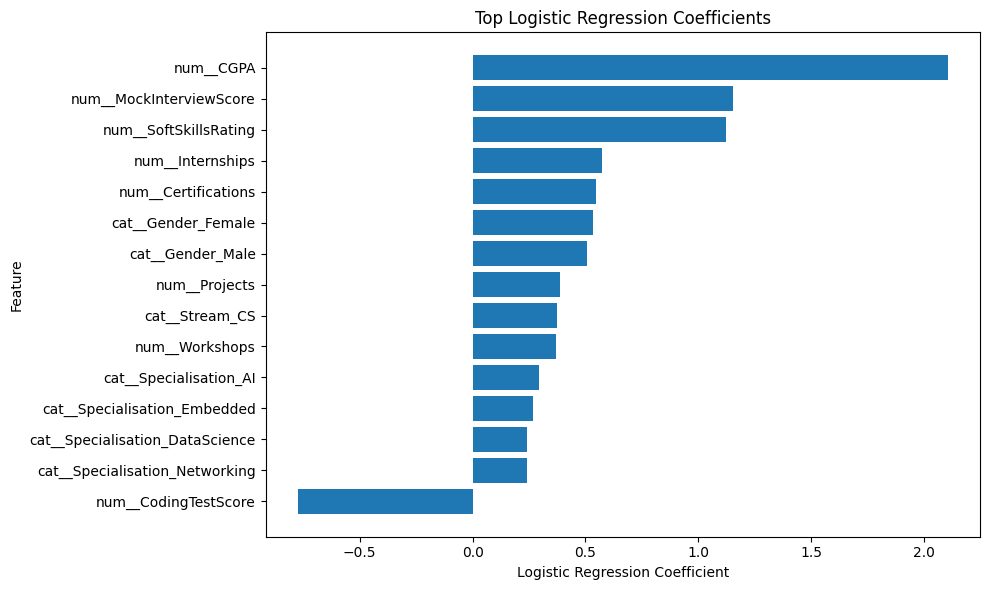

In [ ]:
top_coef = coef_df.head(15).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_coef["Feature"],
    top_coef["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Logistic Regression Coefficients")

plt.tight_layout()
plt.show()

Step 19 — Final results

In [ ]:
binary_val_pred = binary_model.predict(X_val_binary)
multi_val_pred = multinomial_model.predict(X_val_multi)

binary_acc = accuracy_score(
    y_val_binary,
    binary_val_pred
)

multi_acc = accuracy_score(
    y_val_multi,
    multi_val_pred
)

print("========== EXPERIMENT 4 RESULTS ==========")

print(
    f"Binary Logistic Regression Accuracy: "
    f"{binary_acc:.4f}"
)

print(
    f"Multinomial Logistic Regression Accuracy: "
    f"{multi_acc:.4f}"
)

========== EXPERIMENT 4 RESULTS ==========
Binary Logistic Regression Accuracy: 0.8913
Multinomial Logistic Regression Accuracy: 0.6344
